# Module 1 — Data Understanding

**Đề tài:** Traffic Accident Severity Prediction (US Accidents)
**Môn:** DAP391m — AI & Data Science with Python & SQL, Fall 2026
**Lớp:** AI2003 — Giảng viên: Lê Nhật Tùng
**Nhóm:** Group 7
**Thành viên:**
- Lê Huy Hùng — SE204967
- Nguyễn Thiện Nhân — SE203924
- Đặng Gia Bảo — SE203977

**Bộ dữ liệu:** US Accidents (2016–2023) — Sobhan Moosavi, Kaggle (~7.7 triệu dòng, 46 cột)
Link: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
Giấy phép: CC BY-NC-SA 4.0

**Biến mục tiêu:** `Severity` (1 = nhẹ nhất, 4 = nghiêm trọng nhất)

---

### Pipeline của notebook này (Module 1 — Data Understanding)
1. Hiểu dữ liệu (Data Understanding)
2. Khám phá dữ liệu (Exploratory Data Analysis)
3. Xử lý Missing Data
4. Xử lý Outliers
5. Chuẩn hóa & Transform Data
6. Xử lý dữ liệu trùng lặp
7. Kiểm tra và validate kết quả
8. Lưu dữ liệu sạch

> Output của notebook: `cleaned_us_accidents.csv` — dùng cho Module 2 (SQL & Python nâng cao), Module 3 (Visualization), Module 5 (Modeling cho RQ2).

## Bước 0. Setup & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['font.size'] = 10

print('Libraries imported successfully.')

Libraries imported successfully.


## BƯỚC 1 — Hiểu dữ liệu (Data Understanding)

### 1.1. Load dữ liệu


In [2]:
df = pd.read_csv('US_Accidents_March23.csv', low_memory=False)
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 7,728,394 rows × 46 columns


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.9,NaN,91.0,29.68,10.0,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.9,NaN,100.0,29.65,10.0,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.0,33.3,100.0,29.67,10.0,SW,3.5,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.1,31.0,96.0,29.64,9.0,SW,4.6,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.0,33.3,89.0,29.65,6.0,SW,3.5,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


### 1.2. Cấu trúc dữ liệu và kiểu dữ liệu

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     str    
 1   Source                 str    
 2   Severity               int64  
 3   Start_Time             str    
 4   End_Time               str    
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            str    
 11  Street                 str    
 12  City                   str    
 13  County                 str    
 14  State                  str    
 15  Zipcode                str    
 16  Country                str    
 17  Timezone               str    
 18  Airport_Code           str    
 19  Weather_Timestamp      str    
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)            float6

### 1.3. Phân loại các nhóm biến (liên quan trực tiếp tới RQ1–RQ3)

| Nhóm | Features |
|------|----------|
| **Định danh & thời gian** | `ID`, `Start_Time`, `End_Time` |
| **Vị trí** | `Start_Lat`, `Start_Lng`, `City`, `County`, `State` |
| **Thời tiết** | `Temperature(F)`, `Humidity(%)`, `Pressure(in)`, `Visibility(mi)`, `Wind_Speed(mph)`, `Precipitation(in)`, `Weather_Condition` |
| **Thời điểm trong ngày** | `Sunrise_Sunset` |
| **Hạ tầng đường** | `Crossing`, `Junction`, `Traffic_Signal`, `Stop`, `Roundabout`, `Bump`, `Give_Way`, `Amenity`, `Railway` |
| **Mức ảnh hưởng** | `Distance(mi)` |
| **Target** | `Severity` (1–4) |

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f'Numeric columns ({len(numeric_cols)}): {numeric_cols}')
print(f'\nCategorical/bool columns ({len(categorical_cols)}): {categorical_cols}')

df[numeric_cols].describe().T

Numeric columns (13): ['Severity', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

Categorical/bool columns (33): ['ID', 'Source', 'Start_Time', 'End_Time', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Wind_Direction', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


,count,mean,std,min,25%,50%,75%,max
Severity,7728394.0,2.212384,0.487531,1.000000,2.000000,2.000000,2.000000,4.000000
Start_Lat,7728394.0,36.201195,5.076079,24.554800,33.399631,35.823974,40.084959,49.002201
Start_Lng,7728394.0,-94.702545,17.391756,-124.623833,-117.219396,-87.766616,-80.353676,-67.113167
End_Lat,4325632.0,36.261829,5.272905,24.566013,33.462070,36.183495,40.178920,49.075000
End_Lng,4325632.0,-95.725570,18.107928,-124.545748,-117.754345,-88.027890,-80.247086,-67.109242
Distance(mi),7728394.0,0.561842,1.776811,0.000000,0.000000,0.030000,0.464000,441.750000
Temperature(F),7564541.0,61.663286,19.013653,-89.000000,49.000000,64.000000,76.000000,207.000000
Wind_Chill(F),5729375.0,58.251048,22.389832,-89.000000,43.000000,62.000000,75.000000,207.000000
Humidity(%),7554250.0,64.831041,22.820968,1.000000,48.000000,67.000000,84.000000,100.000000
Pressure(in),7587715.0,29.538986,1.006190,0.000000,29.370000,29.860000,30.030000,58.630000


In [5]:
print('Phân phối biến mục tiêu Severity:')
severity_counts = df['Severity'].value_counts().sort_index()
print(severity_counts)
print('\nTỷ lệ (%):')
print((severity_counts / len(df) * 100).round(2))

Phân phối biến mục tiêu Severity:
Severity
1      67366
2    6156981
3    1299337
4     204710
Name: count, dtype: int64

Tỷ lệ (%):
Severity
1     0.87
2    79.67
3    16.81
4     2.65
Name: count, dtype: float64


## BƯỚC 2 — Khám phá dữ liệu (Exploratory Data Analysis)

### 2.1. Phân phối Severity (biến mục tiêu)

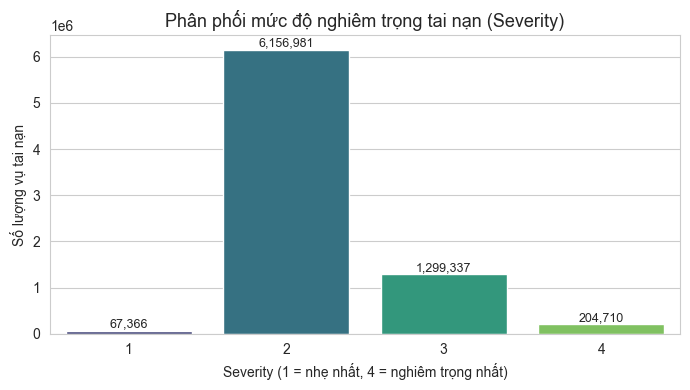

Nhận xét: dữ liệu Severity thường mất cân bằng (imbalanced) — sẽ cần xử lý ở Module 5 (SMOTE/class weighting).


In [6]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(x='Severity', data=df, palette='viridis', order=sorted(df['Severity'].dropna().unique()))
plt.title('Phân phối mức độ nghiêm trọng tai nạn (Severity)')
plt.xlabel('Severity (1 = nhẹ nhất, 4 = nghiêm trọng nhất)')
plt.ylabel('Số lượng vụ tai nạn')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print('Nhận xét: dữ liệu Severity thường mất cân bằng (imbalanced) — sẽ cần xử lý ở Module 5 (SMOTE/class weighting).')

### 2.2. Severity theo điều kiện thời tiết (liên quan RQ1)

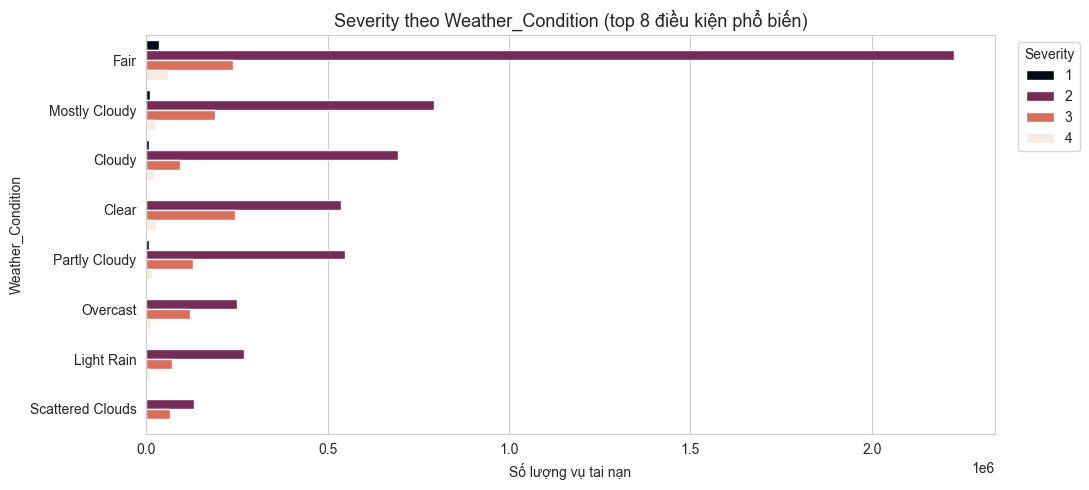

In [7]:
if 'Weather_Condition' in df.columns:
    top_weather = df['Weather_Condition'].value_counts().nlargest(8).index
    df_top_weather = df[df['Weather_Condition'].isin(top_weather)]

    plt.figure(figsize=(11, 5))
    sns.countplot(data=df_top_weather, y='Weather_Condition', hue='Severity',
                  order=top_weather, palette='rocket')
    plt.title('Severity theo Weather_Condition (top 8 điều kiện phổ biến)')
    plt.xlabel('Số lượng vụ tai nạn')
    plt.ylabel('Weather_Condition')
    plt.legend(title='Severity', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

### 2.3. Severity theo thời điểm trong ngày (Sunrise_Sunset) và tầm nhìn (Visibility)

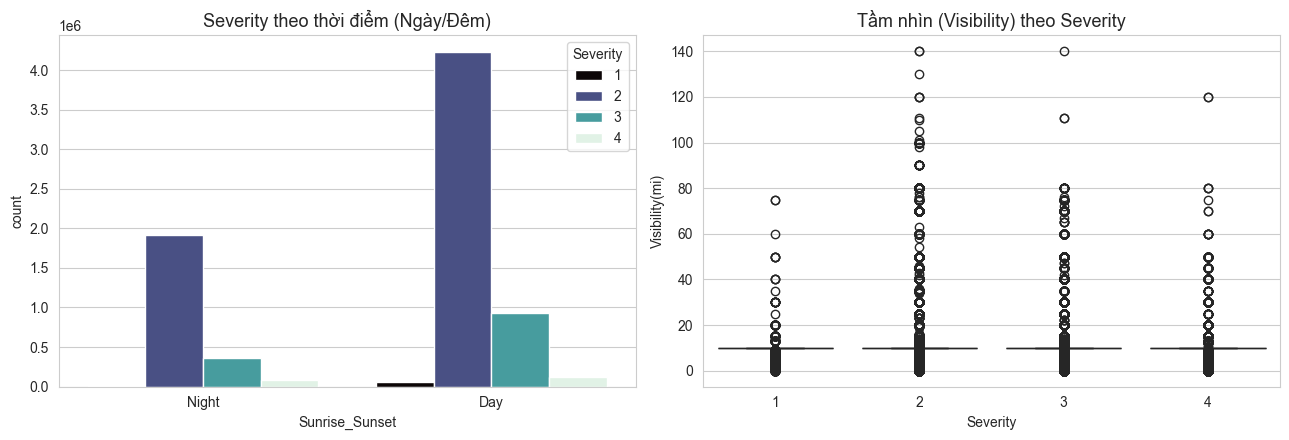

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

if 'Sunrise_Sunset' in df.columns:
    sns.countplot(data=df, x='Sunrise_Sunset', hue='Severity', ax=axes[0], palette='mako')
    axes[0].set_title('Severity theo thời điểm (Ngày/Đêm)')

if 'Visibility(mi)' in df.columns:
    sns.boxplot(data=df, x='Severity', y='Visibility(mi)', ax=axes[1], palette='mako')
    axes[1].set_title('Tầm nhìn (Visibility) theo Severity')

plt.tight_layout()
plt.show()

### 2.4. Tỷ lệ tai nạn nghiêm trọng cao theo hạ tầng đường (liên quan RQ1)

In [9]:
infra_cols = [c for c in ['Crossing', 'Junction', 'Traffic_Signal', 'Stop',
                           'Roundabout', 'Bump', 'Give_Way', 'Amenity', 'Railway'] if c in df.columns]

df['Severity_high'] = (df['Severity'] >= 3).astype(int)

infra_rate = pd.DataFrame({
    col: [
        df.loc[df[col] == True, 'Severity_high'].mean() if (df[col] == True).sum() > 0 else np.nan,
        df.loc[df[col] == False, 'Severity_high'].mean() if (df[col] == False).sum() > 0 else np.nan
    ]
    for col in infra_cols
}, index=['Có hạ tầng (True)', 'Không có (False)']).T

infra_rate = infra_rate.round(3)
print('Tỷ lệ Severity cao (3-4) theo từng loại hạ tầng đường:')
infra_rate

Tỷ lệ Severity cao (3-4) theo từng loại hạ tầng đường:


,Có hạ tầng (True),Không có (False)
Crossing,0.070,0.210
Junction,0.268,0.189
Traffic_Signal,0.095,0.212
Stop,0.062,0.198
Roundabout,0.044,0.195
Bump,0.096,0.195
Give_Way,0.162,0.195
Amenity,0.063,0.196
Railway,0.151,0.195


### 2.5. Ma trận tương quan các biến số

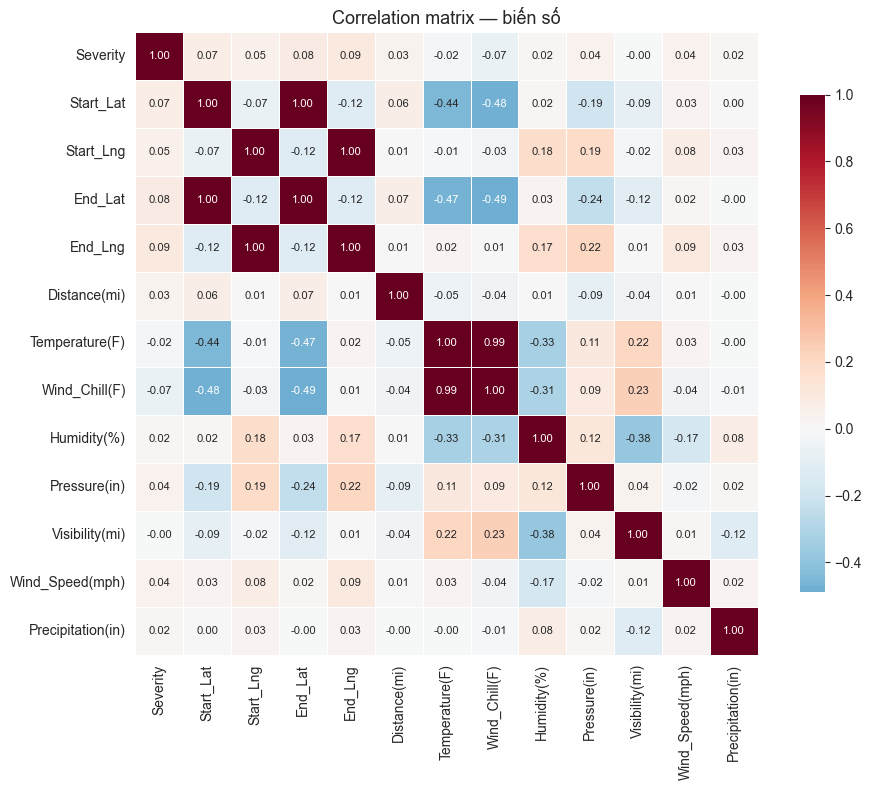

In [10]:
corr_cols = [c for c in numeric_cols if c not in ['Severity_high']]
plt.figure(figsize=(10, 8))
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
plt.title('Correlation matrix — biến số')
plt.tight_layout()
plt.show()

## BƯỚC 3 — Xử lý Missing Data

### 3.1. Kiểm tra missing values

Các cột có missing values:


,Missing Count,Missing %
End_Lat,3402762,44.03
End_Lng,3402762,44.03
Precipitation(in),2203586,28.51
Wind_Chill(F),1999019,25.87
Wind_Speed(mph),571233,7.39
Visibility(mi),177098,2.29
Wind_Direction,175206,2.27
Humidity(%),174144,2.25
Weather_Condition,173459,2.24
Temperature(F),163853,2.12


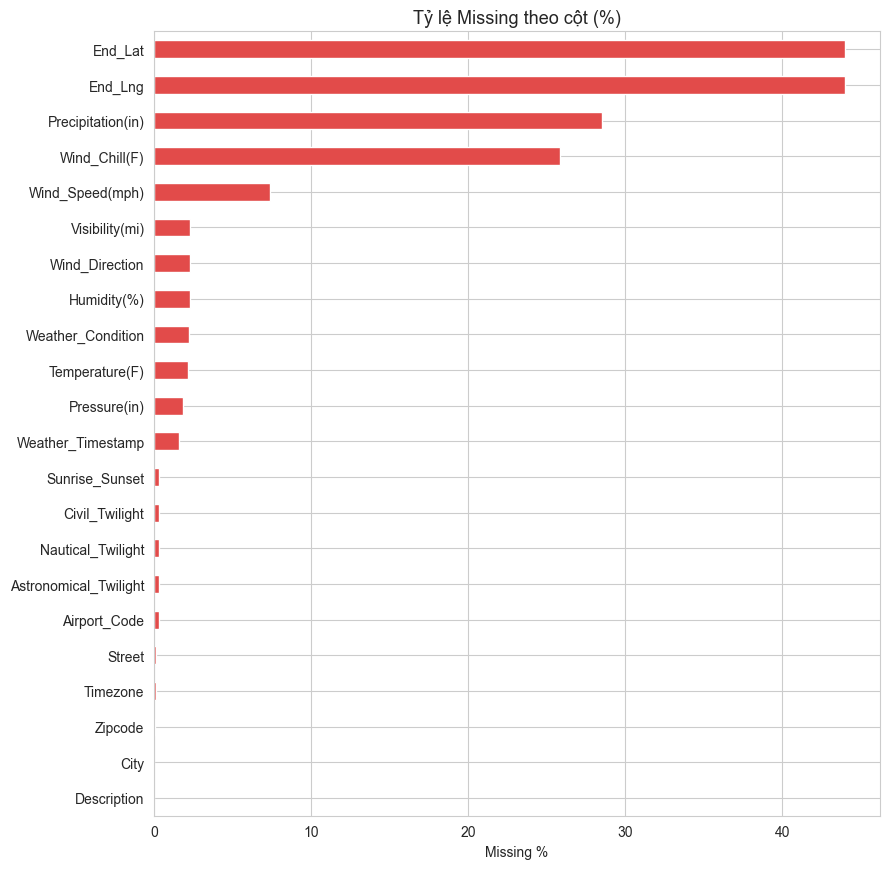

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print('Các cột có missing values:')
display(missing_df)

if len(missing_df) > 0:
    plt.figure(figsize=(9, max(3, 0.4 * len(missing_df))))
    missing_df['Missing %'].plot(kind='barh', color='#E24B4A')
    plt.title('Tỷ lệ Missing theo cột (%)')
    plt.xlabel('Missing %')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('Không có missing values trong dataset.')

### 3.2. Chiến lược xử lý missing

| Loại biến | Chiến lược |
|---|---|
| Biến số liên tục (Temperature, Humidity, Pressure, Visibility, Wind_Speed, Precipitation) | Impute bằng **median** theo nhóm `State` (nếu đủ dữ liệu), fallback bằng median toàn cục |
| Biến phân loại (Weather_Condition, Sunrise_Sunset, City) | Impute bằng **mode** (theo nhóm `State` nếu có, fallback mode toàn cục hoặc 'Unknown') |
| Cột có tỷ lệ missing quá cao (>40%) | Cân nhắc **loại bỏ cột** nếu không quan trọng cho RQ |
| Dòng thiếu `Severity` (target) | **Loại bỏ dòng** vì không thể dùng để huấn luyện/đánh giá |

In [12]:
df_clean = df.copy()

# 3.2.1 Loại bỏ dòng thiếu target
before = len(df_clean)
df_clean = df_clean.dropna(subset=['Severity'])
print(f'Đã loại {before - len(df_clean)} dòng thiếu Severity (target).')

# 3.2.2 Loại cột missing quá cao (>40%)
high_missing_cols = missing_df[missing_df['Missing %'] > 40].index.tolist()
if high_missing_cols:
    df_clean = df_clean.drop(columns=high_missing_cols)
    print(f'Đã loại các cột missing > 40%: {high_missing_cols}')
else:
    print('Không có cột nào missing > 40%.')

# 3.2.3 Impute biến số liên tục bằng median (theo State nếu có, fallback median toàn cục)
numeric_impute_cols = [c for c in ['Temperature(F)', 'Humidity(%)', 'Pressure(in)',
                                    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']
                        if c in df_clean.columns]

for col in numeric_impute_cols:
    n_missing = df_clean[col].isnull().sum()
    if n_missing == 0:
        continue
    if 'State' in df_clean.columns:
        df_clean[col] = df_clean.groupby('State')[col].transform(lambda s: s.fillna(s.median()))
    global_median = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(global_median)
    print(f'  {col:<20} -> imputed {n_missing} values (median theo State, fallback global median = {global_median:.2f})')

# 3.2.4 Impute biến phân loại bằng mode (bao gồm Weather_Condition, Sunrise_Sunset, City)
categorical_impute_cols = [c for c in ['Weather_Condition', 'Sunrise_Sunset', 'City'] if c in df_clean.columns]
for col in categorical_impute_cols:
    n_missing = df_clean[col].isnull().sum()
    if n_missing == 0:
        continue
    if 'State' in df_clean.columns:
        df_clean[col] = df_clean.groupby('State')[col].transform(
            lambda s: s.fillna(s.mode()[0] if not s.mode().empty else 'Unknown')
        )
    mode_val = df_clean[col].mode(dropna=True)[0] if not df_clean[col].mode().empty else 'Unknown'
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f'  {col:<20} -> imputed {n_missing} values with mode = "{mode_val}"')

# 3.2.5 Fallback an toàn: Impute triệt để nếu còn bất kỳ cột nào sót missing values
remaining_missing = df_clean.isnull().sum()
remaining_cols = remaining_missing[remaining_missing > 0].index.tolist()
if remaining_cols:
    print(f'\nXử lý fallback cho các cột còn sót missing: {remaining_cols}')
    for col in remaining_cols:
        if pd.api.types.is_numeric_dtype(df_clean[col]):
            med = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(med)
            print(f'  {col:<20} -> fallback imputed median ({med})')
        else:
            mode_v = df_clean[col].mode(dropna=True)[0] if not df_clean[col].mode().empty else 'Unknown'
            df_clean[col] = df_clean[col].fillna(mode_v)
            print(f'  {col:<20} -> fallback imputed mode ("{mode_v}")')

print(f'\nTổng missing values còn lại: {df_clean.isnull().sum().sum()}')

Đã loại 0 dòng thiếu Severity (target).
Đã loại các cột missing > 40%: ['End_Lat', 'End_Lng']
  Temperature(F)       -> imputed 163853 values (median theo State, fallback global median = 64.00)
  Humidity(%)          -> imputed 174144 values (median theo State, fallback global median = 67.00)
  Pressure(in)         -> imputed 140679 values (median theo State, fallback global median = 29.86)
  Visibility(mi)       -> imputed 177098 values (median theo State, fallback global median = 10.00)
  Wind_Speed(mph)      -> imputed 571233 values (median theo State, fallback global median = 7.00)
  Precipitation(in)    -> imputed 2203586 values (median theo State, fallback global median = 0.00)
  Weather_Condition    -> imputed 173459 values with mode = "Fair"
  Sunrise_Sunset       -> imputed 23246 values with mode = "Day"
  City                 -> imputed 253 values with mode = "Miami"

Xử lý fallback cho các cột còn sót missing: ['Description', 'Street', 'Zipcode', 'Timezone', 'Airport_Code', 

## BƯỚC 4 — Xử lý Outliers

Dùng phương pháp **IQR (Interquartile Range)** trên các biến thời tiết liên tục. Với các biến có ý nghĩa vật lý (ví dụ `Temperature(F)`), nhóm sẽ **clip** (giới hạn) giá trị bất hợp lý thay vì xóa dòng, để không mất dữ liệu tai nạn thật.

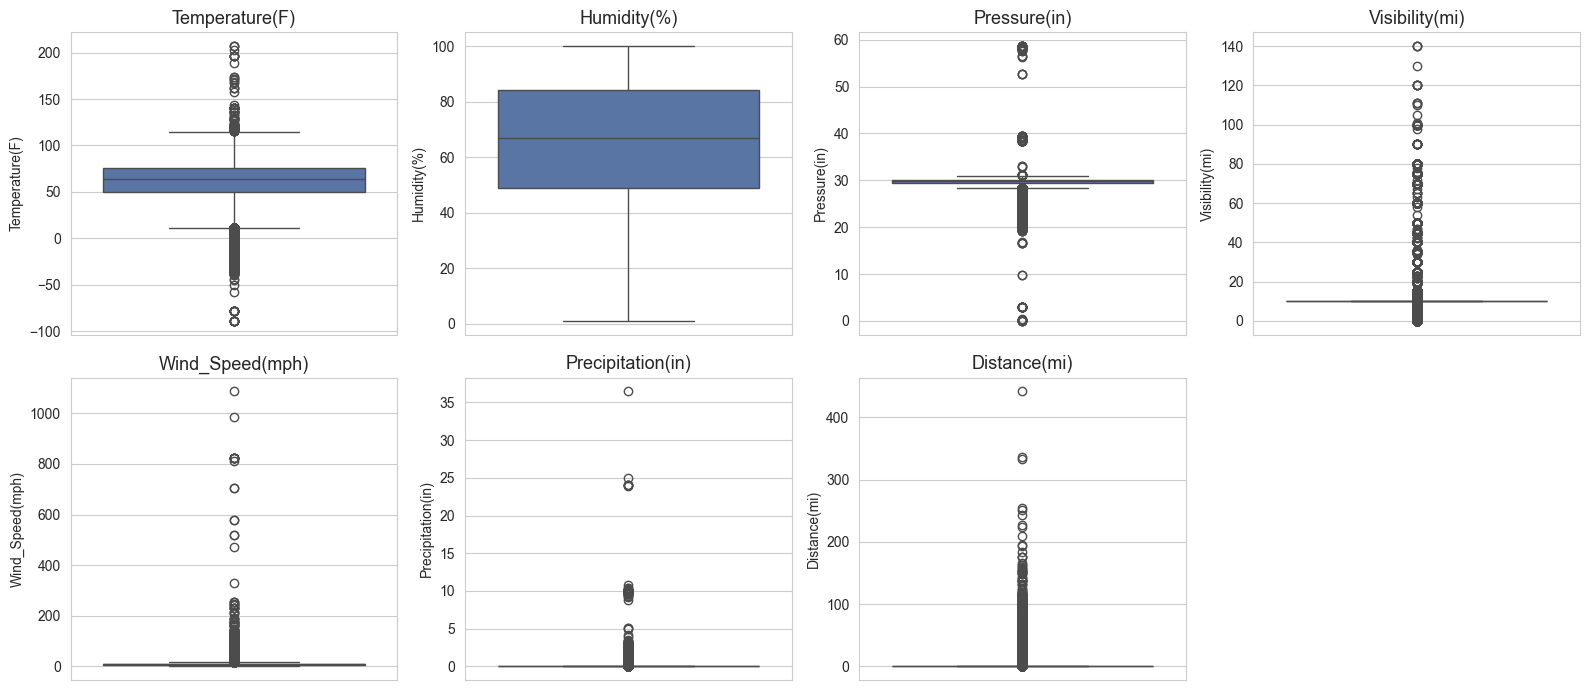

In [13]:
outlier_check_cols = [c for c in ['Temperature(F)', 'Humidity(%)', 'Pressure(in)',
                                   'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',
                                   'Distance(mi)'] if c in df_clean.columns]

n = len(outlier_check_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(outlier_check_cols):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='#4C72B0')
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

In [14]:
def iqr_bounds(series, k=1.5):
    """Tính ngưỡng dưới và ngưỡng trên theo phương pháp IQR."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

# Danh sách các cột về bản chất không thể âm
NON_NEGATIVE_COLS = ['Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)',
                      'Precipitation(in)', 'Distance(mi)']

# Các cột mà giá trị lớn mang tín hiệu quan trọng (không nên bị clip theo IQR thống kê thuần túy)
# -> chỉ loại các giá trị PHI THỰC TẾ (sensor lỗi), không loại các giá trị cực đoan nhưng có thật
DOMAIN_MAX_CAP = {
    'Precipitation(in)': 10.0,   # > 10 inch/giờ gần như chắc chắn lỗi sensor, còn mưa bão thật vẫn giữ
    'Distance(mi)': None,        # để nguyên, không cap cứng — cần xem xét riêng theo phân phối
}

outlier_summary = []
for col in outlier_check_cols:
    lower, upper = iqr_bounds(df_clean[col])

    if upper - lower == 0:
        mode_val = df_clean[col].mode()[0]
        non_mode = df_clean.loc[df_clean[col] != mode_val, col]
        if len(non_mode) > 0:
            lower, upper = iqr_bounds(non_mode)
            lower = min(lower, mode_val)
            upper = max(upper, mode_val)
        else:
            lower, upper = df_clean[col].min(), df_clean[col].max()

    # Ép sàn về 0 cho các biến không thể âm
    if col in NON_NEGATIVE_COLS:
        lower = max(lower, 0)

    # Với các cột mà giá trị lớn có ý nghĩa thực (vd mưa lớn),
    # dùng domain cap thay vì IQR upper bound để tránh xóa tín hiệu thật
    if col in DOMAIN_MAX_CAP and DOMAIN_MAX_CAP[col] is not None:
        upper = DOMAIN_MAX_CAP[col]

    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_summary.append({
        'column': col, 'lower_bound': round(lower, 2), 'upper_bound': round(upper, 2),
        'n_outliers': n_outliers, 'pct_outliers': round(n_outliers / len(df_clean) * 100, 2)
    })
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

outlier_summary_df = pd.DataFrame(outlier_summary)
print('Tóm tắt outliers (đã xử lý bằng clipping theo IQR + domain knowledge):')
outlier_summary_df

Tóm tắt outliers (đã xử lý bằng clipping theo IQR + domain knowledge):


,column,lower_bound,upper_bound,n_outliers,pct_outliers
0,Temperature(F),11.00,115.00,65279,0.84
1,Humidity(%),0.00,136.50,0,0.00
2,Pressure(in),28.38,31.02,453621,5.87
3,Visibility(mi),0.00,13.75,21008,0.27
4,Wind_Speed(mph),0.00,17.50,291148,3.77
5,Precipitation(in),0.00,10.00,60,0.00
6,Distance(mi),0.00,1.16,963606,12.47


## BƯỚC 5 — Chuẩn hóa & Transform Data

### 5.1. Chuẩn hóa kiểu dữ liệu thời gian và tạo đặc trưng thời gian (Time Features)

Tạo các đặc trưng phục vụ RQ1 (thời điểm liên quan tới severity) và RQ2 (feature cho model).

In [15]:
for col in ['Start_Time', 'End_Time']:
    if col in df_clean.columns:
        # format='mixed' để xử lý cả định dạng có nanoseconds (vd: .000000000) và chuẩn ISO
        df_clean[col] = pd.to_datetime(df_clean[col], format='mixed', errors='coerce')

if 'Start_Time' in df_clean.columns:
    df_clean['hour'] = df_clean['Start_Time'].dt.hour
    df_clean['day_of_week'] = df_clean['Start_Time'].dt.dayofweek  # 0 = Monday
    df_clean['month'] = df_clean['Start_Time'].dt.month
    df_clean['year'] = df_clean['Start_Time'].dt.year
    df_clean['is_weekend'] = df_clean['day_of_week'].isin([5, 6]).astype(int)
    df_clean['is_rush_hour'] = df_clean['hour'].isin([7, 8, 9, 16, 17, 18]).astype(int)

if 'Start_Time' in df_clean.columns and 'End_Time' in df_clean.columns:
    df_clean['duration_min'] = (df_clean['End_Time'] - df_clean['Start_Time']).dt.total_seconds() / 60
    df_clean['duration_min'] = df_clean['duration_min'].clip(lower=0)
    # Bù missing cho duration_min nếu có timestamp không hợp lệ
    if df_clean['duration_min'].isnull().sum() > 0:
        df_clean['duration_min'] = df_clean['duration_min'].fillna(df_clean['duration_min'].median())

print('Đã tạo các time features: hour, day_of_week, month, year, is_weekend, is_rush_hour, duration_min')
time_feature_cols = [c for c in ['hour', 'day_of_week', 'month', 'year', 'is_weekend',
                                  'is_rush_hour', 'duration_min'] if c in df_clean.columns]
df_clean[time_feature_cols].head()

Đã tạo các time features: hour, day_of_week, month, year, is_weekend, is_rush_hour, duration_min


,hour,day_of_week,month,year,is_weekend,is_rush_hour,duration_min
0,5,0,2,2016,0,0,314.0
1,6,0,2,2016,0,0,30.0
2,6,0,2,2016,0,0,30.0
3,7,0,2,2016,0,1,30.0
4,7,0,2,2016,0,1,30.0


### 5.2. Encode biến phân loại (cho RQ2 — modeling)

In [16]:
# ============================================
# BƯỚC 5.2 — Encode (MINH HỌA — không lưu vào file cuối)
# ============================================
from sklearn.preprocessing import LabelEncoder

# Dùng biến RIÊNG (df_demo), không đụng vào df_clean
df_demo = df_clean.copy()

infra_cols = [c for c in ['Crossing', 'Junction', 'Traffic_Signal', 'Stop',
                           'Roundabout', 'Bump', 'Give_Way', 'Amenity', 'Railway'] if c in df_clean.columns]

bool_like_cols = [c for c in infra_cols if c in df_demo.columns]
for col in bool_like_cols:
    df_demo[col] = df_demo[col].astype(int)

cat_to_encode = [c for c in ['Weather_Condition', 'Sunrise_Sunset', 'State'] if c in df_demo.columns]
encoders_demo = {}
for col in cat_to_encode:
    le = LabelEncoder()
    df_demo[col + '_enc'] = le.fit_transform(df_demo[col].astype(str))
    encoders_demo[col] = le

print('[MINH HỌA] Đã encode trên toàn bộ dữ liệu để demo kỹ thuật — KHÔNG dùng bản này để train model.')
print('Model thật sẽ fit encoder lại ở Module 5, chỉ trên tập train.')
df_demo[[c + '_enc' for c in cat_to_encode]].head()

[MINH HỌA] Đã encode trên toàn bộ dữ liệu để demo kỹ thuật — KHÔNG dùng bản này để train model.
Model thật sẽ fit encoder lại ở Module 5, chỉ trên tập train.


,Weather_Condition_enc,Sunrise_Sunset_enc,State_enc
0,62,1,33
1,62,1,33
2,88,1,33
3,85,1,33
4,85,0,33


### 5.3. Chuẩn hóa biến số (scaling) 


In [17]:
# ============================================
# BƯỚC 5.3 — Scale (MINH HỌA — không lưu vào file cuối)
# ============================================
from sklearn.preprocessing import StandardScaler

scale_cols = [c for c in ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
                           'Wind_Speed(mph)', 'Precipitation(in)', 'Distance(mi)'] if c in df_demo.columns]

scaler_demo = StandardScaler()
scaled_values = scaler_demo.fit_transform(df_demo[scale_cols])
scaled_df = pd.DataFrame(scaled_values, columns=[c + '_scaled' for c in scale_cols], index=df_demo.index)
df_demo = pd.concat([df_demo, scaled_df], axis=1)

print('[MINH HỌA] Đã scale trên toàn bộ dữ liệu để demo — KHÔNG dùng bản này để train model.')
df_demo[[c + '_scaled' for c in scale_cols]].describe().T[['mean', 'std']].round(3)

[MINH HỌA] Đã scale trên toàn bộ dữ liệu để demo — KHÔNG dùng bản này để train model.


,mean,std
Temperature(F)_scaled,0.0,1.0
Humidity(%)_scaled,0.0,1.0
Pressure(in)_scaled,0.0,1.0
Visibility(mi)_scaled,-0.0,1.0
Wind_Speed(mph)_scaled,0.0,1.0
Precipitation(in)_scaled,-0.0,1.0
Distance(mi)_scaled,0.0,1.0


## BƯỚC 6 — Xử lý dữ liệu trùng lặp

Kiểm tra trùng lặp theo:
1. Toàn bộ dòng (full duplicate)
2. `ID` (nếu có, id phải là duy nhất)

In [18]:
n_full_dup = df_clean.duplicated().sum()
print(f'Số dòng trùng lặp hoàn toàn: {n_full_dup}')

if 'ID' in df_clean.columns:
    n_id_dup = df_clean['ID'].duplicated().sum()
    print(f'Số ID trùng lặp: {n_id_dup}')
else:
    n_id_dup = 0

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
if 'ID' in df_clean.columns:
    df_clean = df_clean.drop_duplicates(subset=['ID'], keep='first')
after = len(df_clean)

print(f'\nĐã loại {before - after} dòng trùng lặp. Shape sau khi loại trùng: {df_clean.shape}')

Số dòng trùng lặp hoàn toàn: 0
Số ID trùng lặp: 0

Đã loại 0 dòng trùng lặp. Shape sau khi loại trùng: (7728394, 52)


## BƯỚC 7 — Kiểm tra và Validate kết quả

Kiểm tra lại toàn bộ pipeline trước khi lưu:
1. Không còn missing values (trên các cột đã xử lý)
2. Không còn dòng trùng lặp
3. Không có outliers cực đoan còn sót lại (biến số trong khoảng hợp lý)
4. Kiểu dữ liệu đúng như kỳ vọng
5. Phân phối Severity không đổi bất thường so với trước xử lý

In [19]:
validation_report = {}

# 1. Missing values còn lại
validation_report['total_missing'] = int(df_clean.isnull().sum().sum())

# 2. Duplicate rows
validation_report['duplicate_rows'] = int(df_clean.duplicated().sum())

# 3. Kiểm tra range hợp lý của các biến then chốt
range_checks = {}
if 'Severity' in df_clean.columns:
    range_checks['Severity in [1,4]'] = df_clean['Severity'].between(1, 4).all()
if 'Humidity(%)' in df_clean.columns:
    range_checks['Humidity in [0,100]'] = df_clean['Humidity(%)'].between(0, 100).all()
if 'hour' in df_clean.columns:
    range_checks['hour in [0,23]'] = df_clean['hour'].between(0, 23).all()
validation_report['range_checks'] = range_checks

# 4. Kiểu dữ liệu
validation_report['dtypes_sample'] = df_clean.dtypes.astype(str).to_dict()

# 5. So sánh phân phối Severity trước/sau xử lý
severity_before = df['Severity'].value_counts(normalize=True).sort_index().round(4)
severity_after = df_clean['Severity'].value_counts(normalize=True).sort_index().round(4)
severity_compare = pd.DataFrame({'before': severity_before, 'after': severity_after})

print('=== VALIDATION REPORT ===')
print(f"Total missing values: {validation_report['total_missing']}")
print(f"Duplicate rows: {validation_report['duplicate_rows']}")
print('\nRange checks:')
for k, v in range_checks.items():
    status = 'PASS' if v else 'FAIL'
    print(f'  [{status}] {k}')

print('\nSo sánh phân phối Severity trước/sau xử lý:')
display(severity_compare)

if validation_report['total_missing'] > 0:
    print('\n⚠️ Chi tiết các cột còn missing:')
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

assert validation_report['total_missing'] == 0, 'Vẫn còn missing values, cần kiểm tra lại Bước 3!'
assert validation_report['duplicate_rows'] == 0, 'Vẫn còn dòng trùng lặp, cần kiểm tra lại Bước 6!'
print('\n✔ Dữ liệu đã đạt yêu cầu validate, sẵn sàng để lưu.')

=== VALIDATION REPORT ===
Total missing values: 0
Duplicate rows: 0

Range checks:
  [PASS] Severity in [1,4]
  [PASS] Humidity in [0,100]
  [PASS] hour in [0,23]

So sánh phân phối Severity trước/sau xử lý:


,before,after
Severity,,
1,0.0087,0.0087
2,0.7967,0.7967
3,0.1681,0.1681
4,0.0265,0.0265



✔ Dữ liệu đã đạt yêu cầu validate, sẵn sàng để lưu.


In [20]:
print(f'Shape ban đầu (trước xử lý):  {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Shape sau xử lý (final):      {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns')
print(f'\nSố cột mới được tạo thêm: {df_clean.shape[1] - df.shape[1]}')
print('\nDanh sách toàn bộ cột trong dataset đã làm sạch:')
print(df_clean.columns.tolist())

Shape ban đầu (trước xử lý):  7,728,394 rows x 47 columns
Shape sau xử lý (final):      7,728,394 rows x 52 columns

Số cột mới được tạo thêm: 5

Danh sách toàn bộ cột trong dataset đã làm sạch:
['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Severity_high', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_rush_hour', 'duration_min']


## BƯỚC 8 — Lưu dữ liệu sạch (Save Clean Data)

Xuất dataset đã làm sạch và feature-engineered để dùng cho:
- **Module 2** — SQL & Python nâng cao
- **Module 3** — Data Visualization nâng cao (RQ1, RQ3 hotspot)
- **Module 5** — Xây dựng mô hình phân loại (RQ2)

In [21]:
OUTPUT_CSV = 'cleaned_us_accidents.csv'
OUTPUT_PARQUET = 'cleaned_us_accidents.parquet'

df_clean.to_csv(OUTPUT_CSV, index=False)
print(f'Saved: {OUTPUT_CSV}')

try:
    df_clean.to_parquet(OUTPUT_PARQUET, index=False)
    print(f'Saved: {OUTPUT_PARQUET} (khuyến nghị dùng cho các module sau vì đọc/ghi nhanh hơn với dữ liệu lớn)')
except Exception as e:
    print(f'Không lưu được parquet (thiếu thư viện pyarrow/fastparquet?): {e}')

print(f'\nFinal dataset: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns')

Saved: cleaned_us_accidents.csv
Không lưu được parquet (thiếu thư viện pyarrow/fastparquet?): Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

Final dataset: 7,728,394 rows x 52 columns


## Tổng kết Module 1 — Data Understanding

### Đã hoàn thành theo đúng 8 bước pipeline:
1. ✅ **Hiểu dữ liệu** — load dataset, xác định cấu trúc, phân nhóm biến, biến mục tiêu `Severity`
2. ✅ **EDA** — phân phối Severity, mối quan hệ với thời tiết/thời điểm/hạ tầng đường, correlation matrix
3. ✅ **Xử lý Missing Data** — loại dòng thiếu target, loại cột missing quá cao, impute median/mode
4. ✅ **Xử lý Outliers** — phát hiện bằng IQR, xử lý bằng clipping (giữ nguyên số vụ tai nạn)
5. ✅ **Chuẩn hóa & Transform** — tạo time features (hour, day_of_week, is_weekend, is_rush_hour...), encode biến phân loại, scale biến số
6. ✅ **Xử lý trùng lặp** — kiểm tra và loại bỏ duplicate rows/ID
7. ✅ **Validate kết quả** — kiểm tra missing = 0, duplicate = 0, range hợp lệ, phân phối Severity ổn định
8. ✅ **Lưu dữ liệu sạch** — xuất `cleaned_us_accidents.csv` / `.parquet`

### Liên kết với 3 câu hỏi nghiên cứu (RQ):
| RQ | Đóng góp của Module 1 |
|----|------------------------|
| **RQ1** (điều kiện liên quan tới severity cao) | EDA mục 2.2–2.4 (thời tiết, thời điểm, hạ tầng) + time features ở Bước 5 |
| **RQ2** (mô hình phân loại Severity) | Toàn bộ pipeline làm sạch + encode + scale ở Bước 3–5 tạo input sẵn sàng cho modeling |
| **RQ3** (bản đồ hotspot) | Giữ nguyên `Start_Lat`, `Start_Lng` sạch, không outlier, phục vụ Module 3 |

### Bước tiếp theo:
**Module 2 — Data Analysis with SQL and Python (nâng cao)**: viết pipeline SQL nâng cao, phân tích sâu hơn trên `cleaned_us_accidents.csv` — người phụ trách theo kế hoạch: **Đặng Gia Bảo**.

> ⚠️ Lưu ý: Khi có file dataset US Accidents thật (`US_Accidents_March23.csv` từ Kaggle), chỉ cần đặt file vào cùng thư mục với notebook và chạy lại từ đầu — pipeline sẽ tự động dùng dữ liệu thật thay vì dữ liệu giả lập (synthetic).